In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


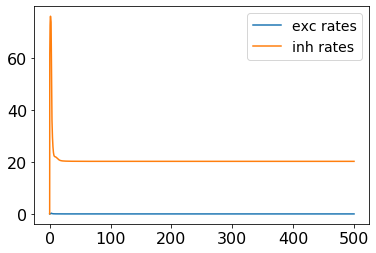

[5.5702e-05 2.0196e+01]


In [2]:
aln = ALNModel()

aln.params['duration'] = 500.

# no noise
aln.params.sigma_ou = 0.

control0 = aln.getZeroControl()

# external currents for steady state
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()
    
steady_rates = np.zeros((2))
steady_rates[0] = aln.rates_exc[0,-1]
steady_rates[1] = aln.rates_inh[0,-1]

print(steady_rates)

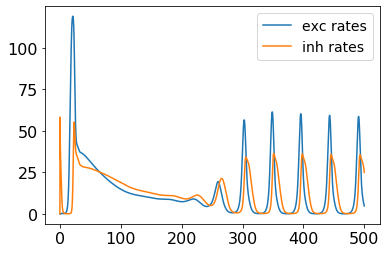

In [3]:
# external currents for oscillation
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 0.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

state_vars = aln.state_vars

osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        osc_init[i] = aln.state[state_vars[i]][0]
    else:
        osc_init[i] = aln.state[state_vars[i]][0,-1]

In [4]:
init_vars = aln.init_vars

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

In [37]:
dur = 3000.
dur_pre = 100.
dur_post = 500.
aln.params.duration = dur

tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

## C) Oscillation to high state
- adaptation
- default delay
- max control current 5nA
- w_p = w_e = w_s = 1

In [38]:
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 5. * 5.

setinitvars(osc_init)
max_it = 10
alg = "A1"
case = "C"

aln.params.duration = dur

# set high state rates as target
target_A1 = aln.getZeroTarget()
target_A1[:,0,:] = steady_rates[0]
target_A1[:,1,:] = steady_rates[1] 

control0 = aln.getZeroControl()
#control0[:,1,:] =1.5
control0[:,1,:] =2.5

bestControlA_A1, bestStateA_A1, costA_A1, runtimeA_A1 = aln.A1(control0, target_A1, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  365220.0679465671
RUN  1 , total integrated cost =  6896.930696417854
RUN  2 , total integrated cost =  6163.493363308292
RUN  3 , total integrated cost =  6153.339677750263
RUN  4 , total integrated cost =  6149.108605104569
RUN  5 , total integrated cost =  6146.353993720447
RUN  6 , total integrated cost =  6144.267027045669
RUN  7 , total integrated cost =  6142.542219837466
RUN  8 , total integrated cost =  6141.078674765979
RUN  9 , total integrated cost =  6139.802466649907


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  6138.683932887745
Improved over  10  iterations by  98.31918219406666  percent.
Problem in initial value trasfer:  Vmean_exc -61.416701734408456 -61.4923657534808
Problem in initial value trasfer:  Vmean_exc -72.28487530382473 -72.2849627146127


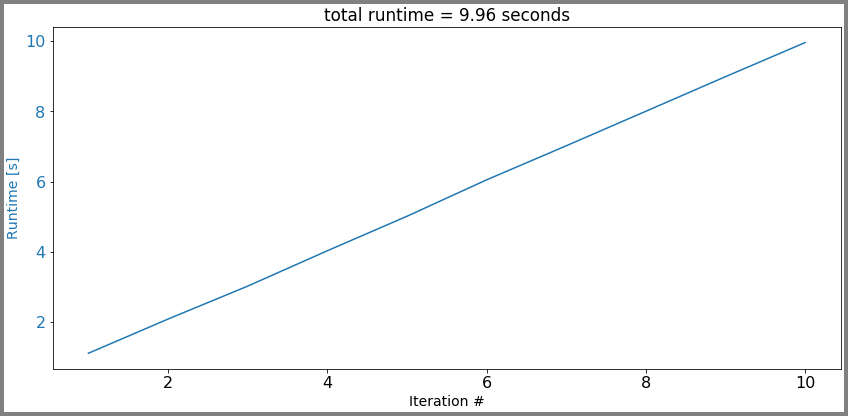

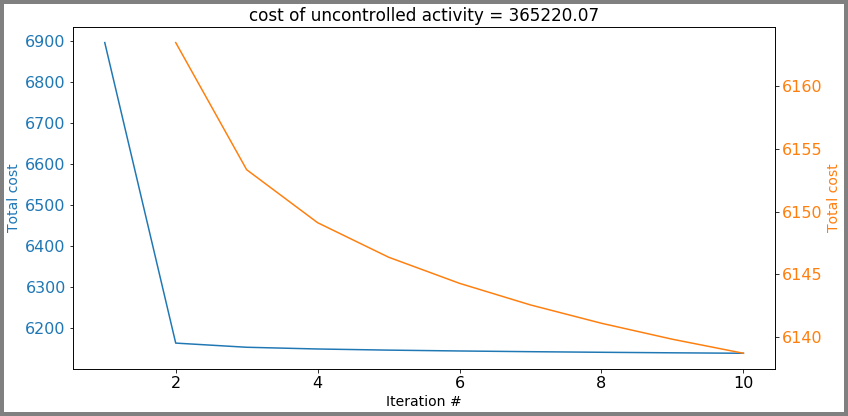

In [39]:
plotFunc.plot_runtime(runtimeA_A1, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A1, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

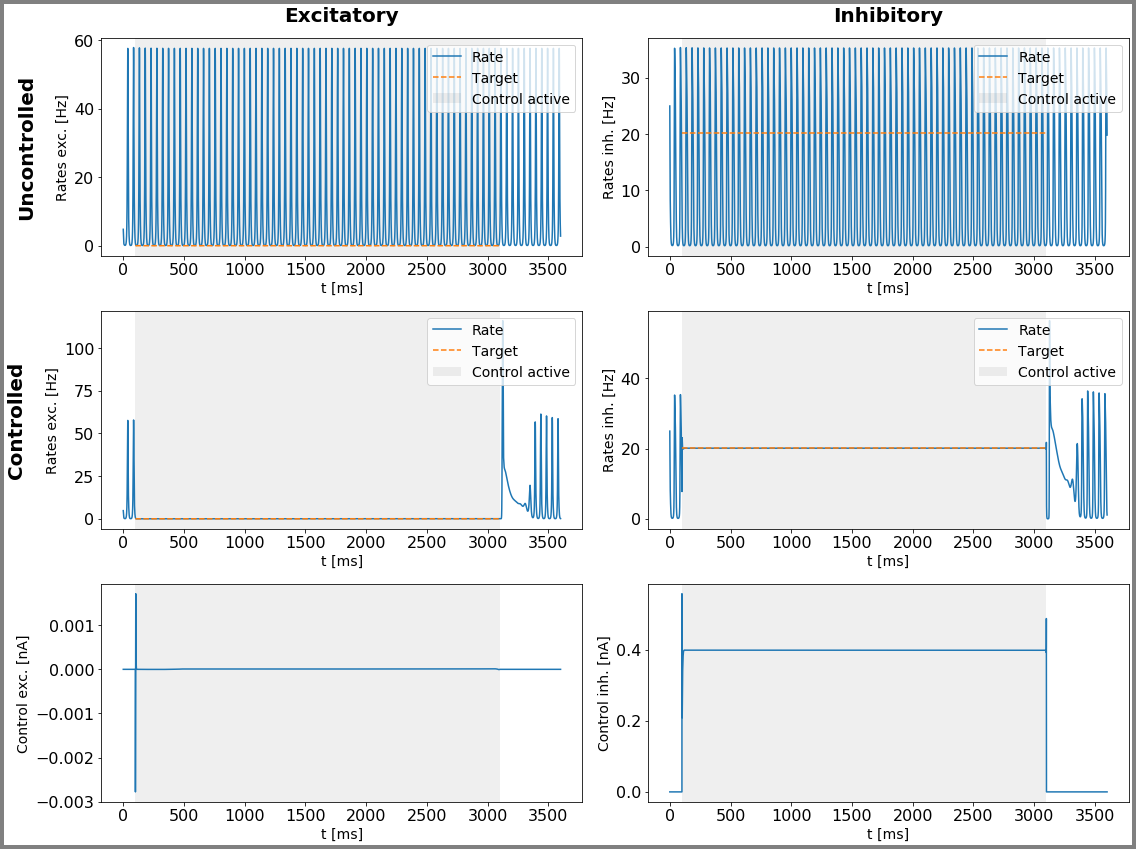

In [40]:
plotFunc.plot_control(aln, bestControlA_A1, dur, dur_pre, dur_post, osc_init, target_A1,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

In [41]:
dur = 100.
dur_pre = 100.
dur_post = 100.
aln.params.duration = dur

setinitvars(osc_init)
max_it = 3
alg = "A2"
case = "C"

aln.params.duration = dur

# set high state rates as target
target_A2 = aln.getZeroTarget()
target_A2[:,0,:] = steady_rates[0]
target_A2[:,1,:] = steady_rates[1] 
control0 = aln.getZeroControl()


bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control0, target_A2,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

RUN  0 , total integrated cost:  31567.696076877724
RUN  1 , total integrated cost:  11458.276583034702
RUN  2 , total integrated cost:  10497.181608930148


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost:  10175.388630110469
Improved over  3  iterations by  68  percent.
Problem in initial value trasfer:  Vmean_exc -61.416701734408456 -61.4923657534808
Problem in initial value trasfer:  Vmean_exc -64.60883720064473 -64.7129593573893


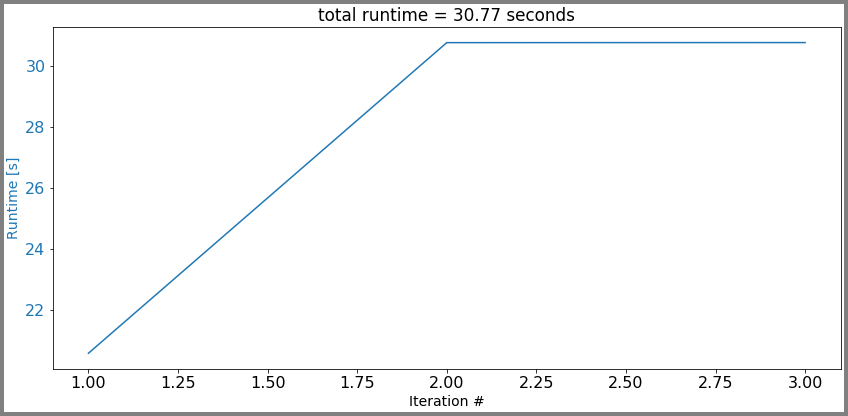

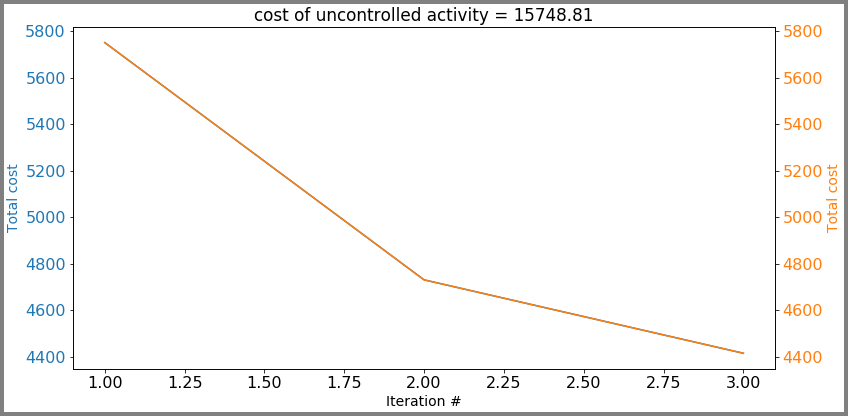

In [35]:
plotFunc.plot_runtime(runtimeA_A2, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A2, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

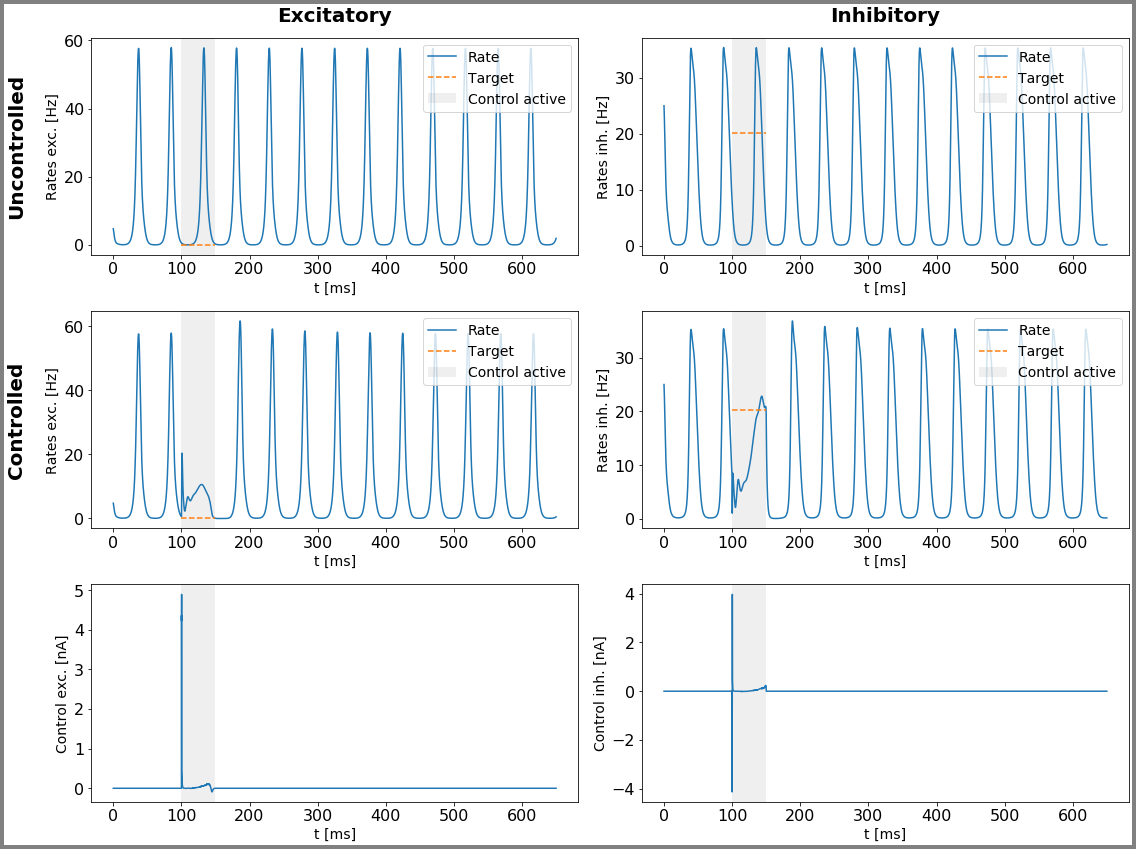

In [36]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, osc_init, target_A2,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))